## Image-to-Image (I2I) Network Demo Notebook

In this notebook we show how STUN is trained and evaluated on non-stationary, spatial data. This notebook is intended to be a tutorial/demonstration. 

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np 
from Typing import Optional
from skimage.metrics import (
	structural_similarity as ssim_metric,
	peak_signal_noise_ratio as psnr_metric,
)

import time

# directly import from latticevision library in directory
from latticevision.device import set_device
from latticevision.img2img.dataset import (
	make_dataset,
	DataConfig,
)
from latticevision.plotting import plot_example_field, plot_losses, plot_img2img_samples
from latticevision.img2img import TransUNet
from latticevision.img2img.base import (
	ModelConfig,
	NullPosEmbed,
	LearnedPosEmbed,
	SinusoidalPosEmbed,
	RotaryPosEmbed,
)
from latticevision.img2img.train import train_model, TrainingConfig
from latticevision.img2img.eval import eval_model
from latticevision.seed import set_all_random_seeds

The `set_device` function from `device.py` is used to set the device based on whether you are running this work locally or on a remote server with named GPUs. 

In [2]:
# set random seed for reproducibility
set_all_random_seeds(777)

# for remote use
device = set_device(machine="remote", gpu=True, gpu_id="cuda:0", verbose=True)

# for local use
# device = set_device(machine="local", gpu=True, verbose=True)

Using device: cuda:0 
Hardware:  NVIDIA RTX A6000


The `make_dataset` function from `dataset.py` returns the extracted fields, awghts, and configs from the hdf5 file, and creates our train, val, and test datasets for us. 

In [3]:
# for testing
# dataset_path = "../data/I2I_sample_data.h5"
# val_size = 0.4
# test_size = 0.5

dataset_path = "../data/I2I_data.h5"
val_size = 0.1
test_size = 0.2

data_config = DataConfig(
	file_path=dataset_path,
	n_rows=128,
	n_cols=128,
	n_replicates=30,
	n_params=3,
	log_kappa2=True,
	shift_theta=True,
	val_size=val_size,
	test_size=test_size,
	random_state=777,
	verbose=True,
)

data_dict = make_dataset(
	config=data_config,
)

train_df = data_dict["train_df"]
val_df = data_dict["val_df"]
test_df = data_dict["test_df"]

Components in the file: ['fields']
Dataset size (MB):  82500.0001373291
Dataset size (GB):  80.56640638411045
Fields shape:  (20000, 30, 128, 128)
Params shape:  (20000, 3, 128, 128)
Train fields shape:  (18000, 30, 128, 128)
Train params shape:  (18000, 3, 128, 128)
Validation fields shape:  (1600, 30, 128, 128)
Validation params shape:  (1600, 3, 128, 128)
Test fields shape:  (400, 30, 128, 128)
Test params shape:  (400, 3, 128, 128)


Let's plot an example field using the `plot_example_field` function from `plotting.py`.

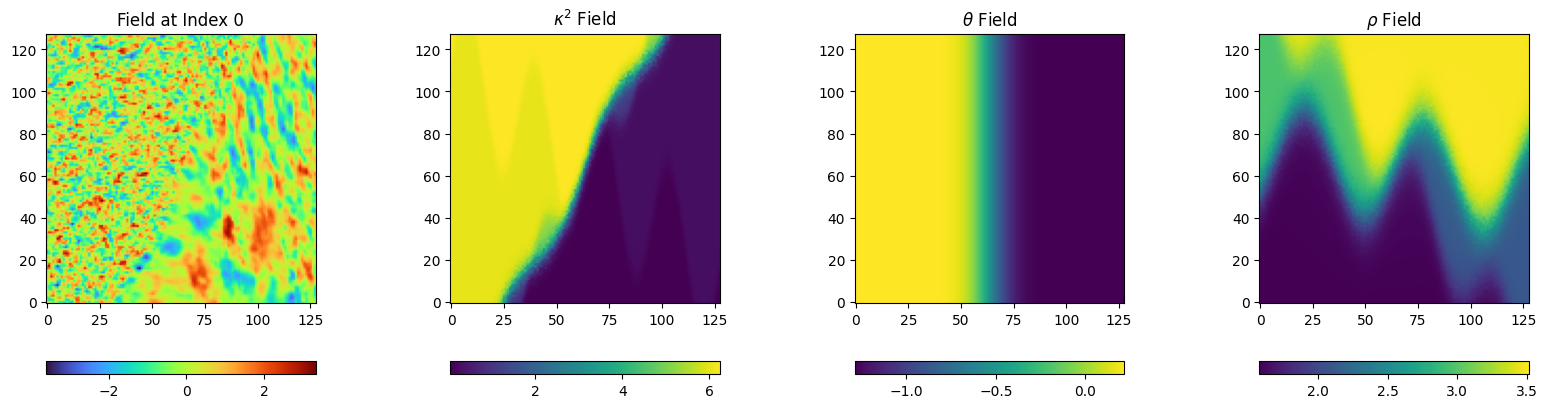

In [4]:
plot_example_field(
	dataset=train_df,
	config=data_config,
	idx=0,
	model_type="STUN",
	field_color="turbo",
	param1_color="viridis",
	param2_color="viridis",
	param3_color="viridis",
)

## Training

We now use the `DataLoader` class from PyTorch to conveniently batch the data. 

In [5]:
n_batch = 64
# n_batch = 2

train_loader = DataLoader(train_df, batch_size=n_batch, shuffle=True)
val_loader = DataLoader(val_df, batch_size=n_batch, shuffle=False)
test_loader = DataLoader(test_df, batch_size=n_batch, shuffle=False)

for fields, params in train_loader:
	print("Train Loader:")
	print(
		"Fields batch shape: ",
		fields.shape,
		"\nParams batch shape: ",
		params.shape,
	)
	break

for fields, params in val_loader:
	print("Val Loader:")
	print(
		"Fields batch shape: ",
		fields.shape,
		"\nParams batch shape: ",
		params.shape,
	)
	break

for fields, params in test_loader:
	print("Test Loader:")
	print(
		"Fields batch shape: ",
		fields.shape,
		"\nParams batch shape: ",
		params.shape,
	)
	break

Train Loader:
Fields batch shape:  torch.Size([64, 30, 128, 128]) 
Params batch shape:  torch.Size([64, 3, 128, 128])
Val Loader:
Fields batch shape:  torch.Size([64, 30, 128, 128]) 
Params batch shape:  torch.Size([64, 3, 128, 128])
Test Loader:
Fields batch shape:  torch.Size([64, 30, 128, 128]) 
Params batch shape:  torch.Size([64, 3, 128, 128])


Now let's pull in our `TransUNet (STUN)` from `stun.py`. We access all of these through the `__init__.py` file in the `img2img` folder.  

In [ ]:
# rotary has been shown to work well in LatticeVision paper
pos_embeds = [NullPosEmbed, LearnedPosEmbed, SinusoidalPosEmbed, RotaryPosEmbed]

config = ModelConfig(
	patch_size_h=2,
	patch_size_w=2,
	pos_embed_cls=pos_embeds[3],
)
model = TransUNet(config)

# send model to device and count params
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of trainable parameters: {total_params}")

Total number of trainable parameters: 105325827


We train our model using `train_model` from `train.py`.

In [9]:
start_time = time.time()

train_config = TrainingConfig(
	model=model,
	device=device,
	train_loader=train_loader,
	val_loader=val_loader,
	train_df=train_df,
	val_df=val_df,
	lr=1e-4,
	n_epochs=3,
	stop_patience=10,
	scheduler_patience=5,
	scheduler_factor=0.5,
	augmentation=True,
	save=False,  # switch to True to save model after training, currently this is just training for show
	save_directory="results/model_wghts/",
	savename="stun_wghts_example.pth",
	verbose=True,
	normalize=True,
	shuffle=True,
)


training_results = train_model(config=train_config)

time_train = time.time() - start_time
print("Training took: ", time_train / 60, " minutes.")

model = training_results["model"]
train_losses = training_results["train_losses"]
baseline_losses = training_results["baseline_losses"]
val_losses = training_results["val_losses"]

Training for 3 epochs with learning rate 0.0001.
Model weights will not be saved.
Augmentation has been enabled.
Normalization has been enabled.
Shuffling has been enabled.
Epoch 1/3
Train Loss: 18.392266 - Base (Mean) Loss: 0.339411 - Val Loss: 7.028646
Learning Rate: 0.000100
Epoch 2/3
Train Loss: 14.645576 - Base (Mean) Loss: 0.339411 - Val Loss: 5.574002
Learning Rate: 0.000100
Epoch 3/3
Train Loss: 12.871477 - Base (Mean) Loss: 0.339411 - Val Loss: 4.804334
Learning Rate: 0.000100
Training complete. Best model weights loaded.
Training took:  0.08235507408777873  minutes.


Let's take a look at the loss with `plot_losses`, another function from `plotting.py` which should work for both the CNN and I2I models. 

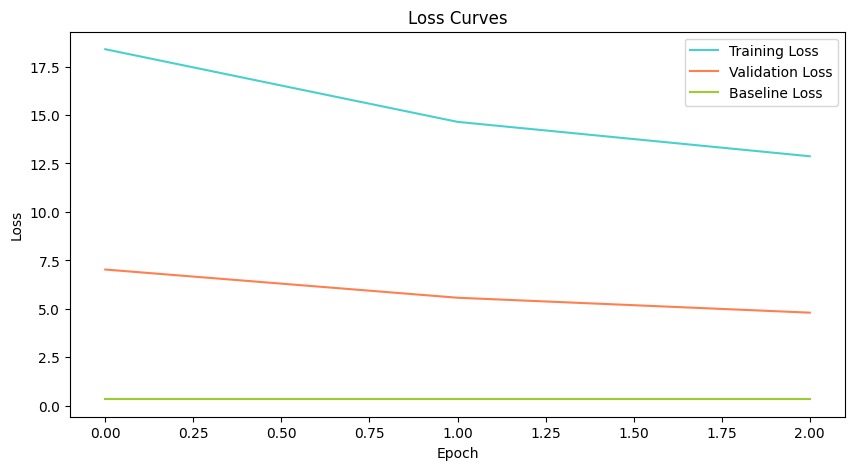

In [10]:
plot_losses(
	train_losses=train_losses,
	val_losses=val_losses,
	base_losses=baseline_losses,
	show=True,
)

The `train_model` function saves the model in `results/model_wghts/` if `save = True`. 

## Evaluation

If we want to load it back up again, **we run everything in the notebook except the two cells in which the training loop and loss plotting code are executed**. Then we continue on through the notebook, beginning with loading the model by using the code below: 

In [6]:
modeltype = "TransUNet"  # can also be "UNet, "ViT"
modelpath = "../results/model_wghts/modelTransUNet_reps30_posRotaryPosEmbed.pth"
n_reps = 30
pos_embeds = [NullPosEmbed, LearnedPosEmbed, SinusoidalPosEmbed, RotaryPosEmbed]

config = ModelConfig(
	in_channels=n_reps,
	patch_size_h=2,
	patch_size_w=2,
	pos_embed_cls=pos_embeds[3],
)
model = TransUNet(config)
model.load_state_dict(torch.load(modelpath))

model = model.to(device)
model.eval()

TransUNet(
  (encoders): ModuleList(
    (0): EncoderBlock(
      (conv): Sequential(
        (0): Conv2d(30, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
        (5): GELU(approximate='none')
      )
      (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncoderBlock(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(16, 128, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(16, 128, eps=1e-05, affine=True)
        (5): GELU(approximate='none')
      )
      (pool): MaxPool2d(kernel_size=(2, 2), stride=(2

This `eval_model` function from `eval.py` calculates a number of metrics and does some plotting. 

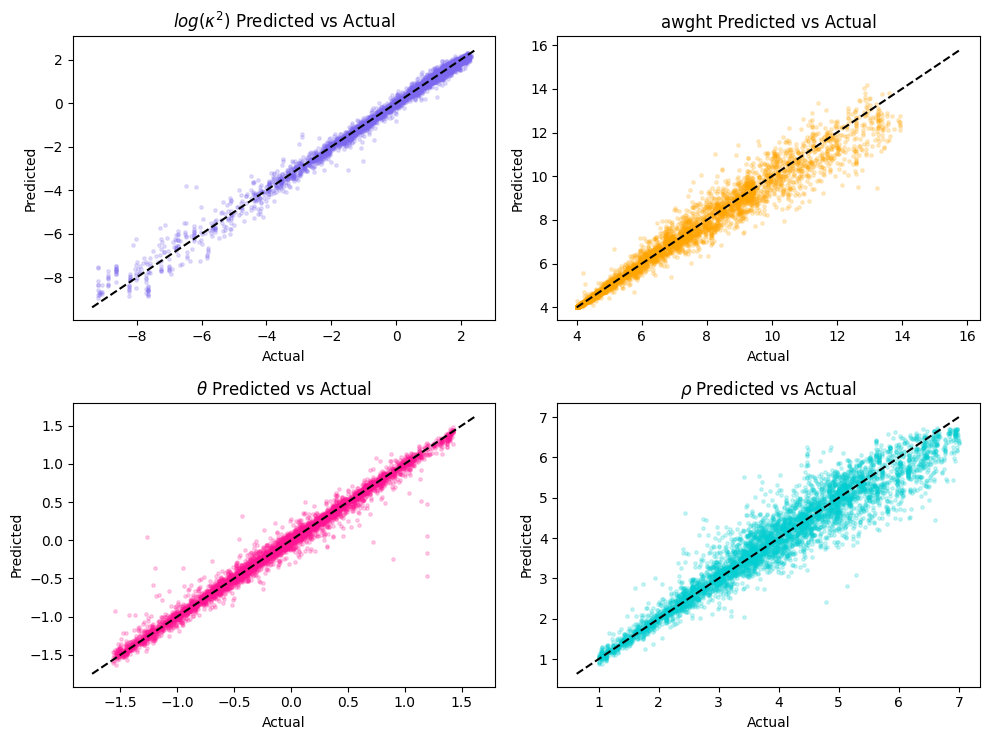

               rmse       mae        r2      ssim       psnr     nrmse  \
parameter                                                                
kappa2     0.216919  0.131704  0.989791  0.549244  18.306734  0.018841   
theta      0.089616  0.050922  0.983238  0.676511  23.098789  0.029872   
rho        0.391241  0.277863  0.922690  0.578551  14.041581  0.065207   

             relerr   relerr5  relerr95  
parameter                                
kappa2     0.723107  0.005913  0.582354  
theta      0.811727  0.005052  1.095066  
rho        0.069958  0.004771  0.192831  


In [7]:
metrics = eval_model(
	model=model,
	config=data_config,
	device=device,
	test_loader=test_loader,
	test_df=test_df,
	plot=True,
	augmentation=False,
	n_pixels=5000,
	show=True,
)

Here we take a couple fields inside of the test data and plot how the model does using `plot_img2img_samples` from `plotting.py`.

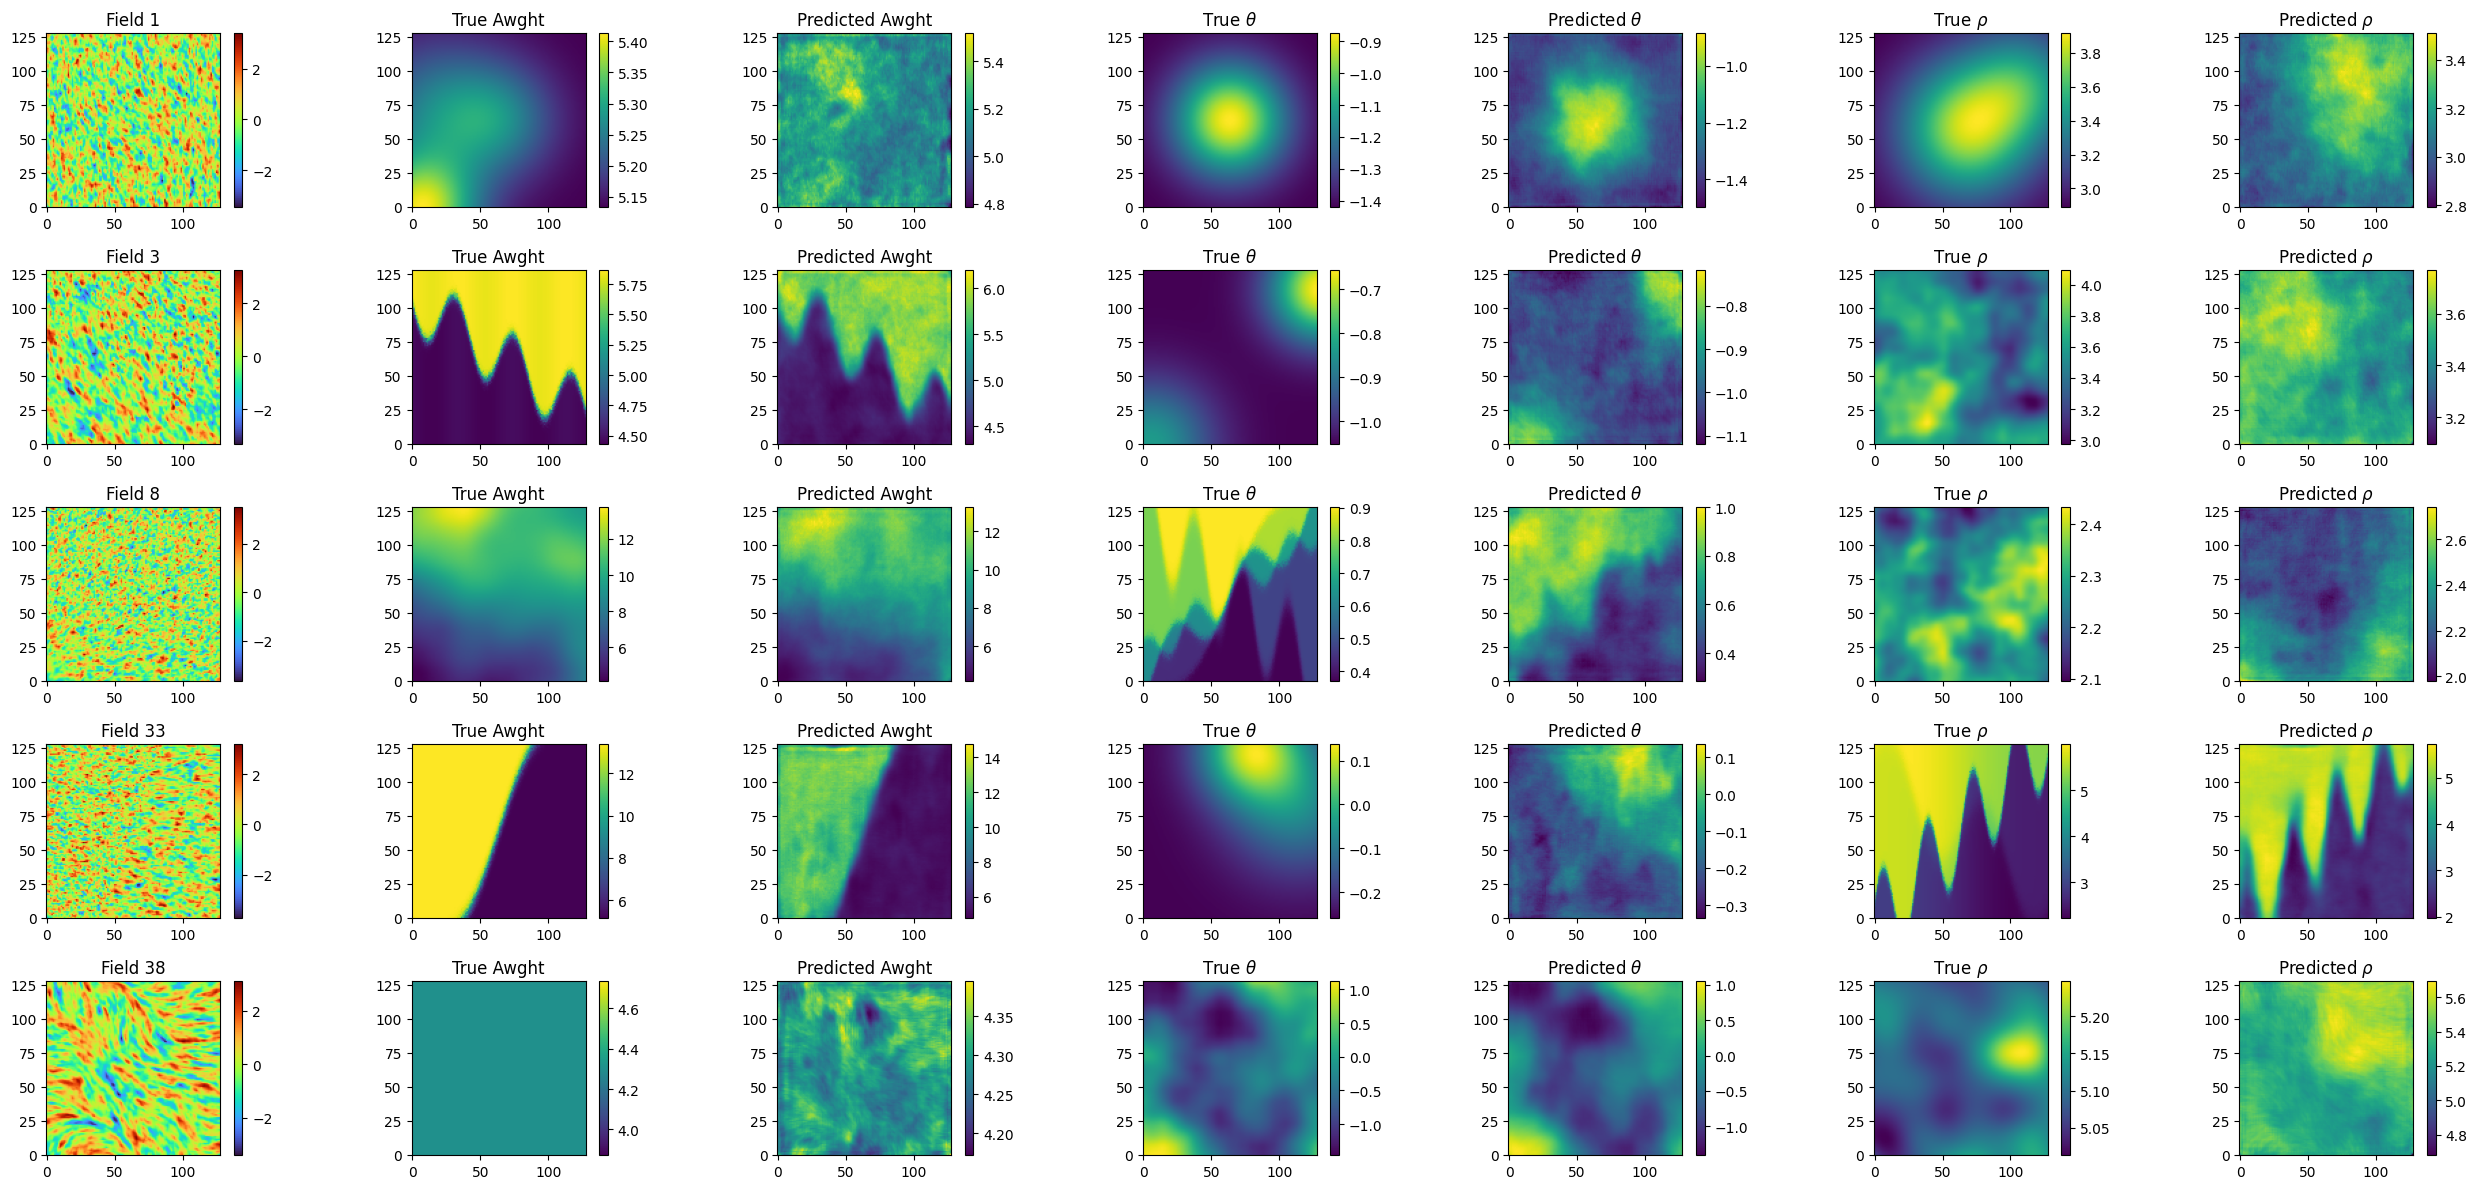

In [8]:
inds = [0, 2, 7, 32, 37]
# inds = [0]  # for test dataset

plot_img2img_samples(
	model=model,
	config=data_config,
	device=device,
	test_df=test_df,
	indices=inds,
	random_selection=False,
	num_rand_samples=5,
	awght_not_kappa2=True,
	show=True,
)

Further verification of estimator accuracy below. 

In [ ]:

def eval_model2(
	model: torch.nn.Module,
	device: torch.device,
	config: DataConfig,
	test_loader: torch.utils.data.DataLoader,
	test_df: torch.utils.data.Dataset,
	plot: bool = True,
	augmentation: bool = False,
	show: bool = True,
	n_pixels: int = 5000,
	cnn_mode: bool = False,
	cnn_results: Optional[torch.tensor] = None,
) -> dict:
	"""
	Evaluates the STUN model on the test set by computing a number of metrics
	for each parameter (kappa2, theta, rho) and optionally plots the predicted
	vs actual values (pixelwise). 

	Metrics computed (for each parameter):
	    - RMSE (Root Mean Squared Error)
	    - MAE (Mean Absolute Error)
	    - R² (Coefficient of Determination)
	    - SSIM (Structural Similarity Index)
	    - PSNR (Peak Signal-to-Noise Ratio)
	    - NRMSE (Normalized RMSE)

	Args:
	    model (nn.Module): The trained model.
		config (DataConfig): Configuration for the dataset.
	    device (torch.device): Device to perform computations on.
	    test_loader (DataLoader): DataLoader for the test set.
	    test_df (Dataset): Test dataset (used only for computing the number of test samples).
	    plot (bool, optional): If True, plots predicted vs actual graphs. Defaults to True.
	    augmentation (bool, optional): If True, applies augmentation. Defaults to False.
		show (bool, optional): If True, shows the plot. Defaults to True.
		n_pixels (int, optional): Number of pixels to sample for the predicted vs actual plot. Defaults to 5000.
		cnn_mode (bool, optional): If True, uses CNN data. Defaults to False.
		cnn_results (Optional[torch.tensor], optional): The CNN results to use for plotting. Defaults to None.

	Returns:
	    dict: Dictionary containing computed metrics for each parameter.
	"""

	model.eval()

	# create dicts for predictions and true values for each param.
	preds = {"kappa2": [], "theta": [], "rho": []}
	truths = {"kappa2": [], "theta": [], "rho": []}

	if cnn_mode == False:
		with torch.no_grad():
			for fields_batch, params_batch in test_loader:
				if augmentation:
					fields_batch, params_batch = fields_batch, params_batch

				fields_batch = fields_batch.to(device)
				params_batch = params_batch.to(device)

				# pass through model
				outputs = model(fields_batch)

				# seaparate params (channel dimension)
				preds["kappa2"].append(outputs[:, 0, :, :].cpu().numpy())
				preds["theta"].append(outputs[:, 1, :, :].cpu().numpy())
				preds["rho"].append(outputs[:, 2, :, :].cpu().numpy())

				truths["kappa2"].append(params_batch[:, 0, :, :].cpu().numpy())
				truths["theta"].append(params_batch[:, 1, :, :].cpu().numpy())
				truths["rho"].append(params_batch[:, 2, :, :].cpu().numpy())
	else:
		outputs = cnn_results
		params_batch = test_df[:][1]
		preds["kappa2"].append(outputs[:, 0, :, :].cpu().numpy())
		preds["theta"].append(outputs[:, 1, :, :].cpu().numpy())
		preds["rho"].append(outputs[:, 2, :, :].cpu().numpy())

		truths["kappa2"].append(params_batch[:, 0, :, :].cpu().numpy())
		truths["theta"].append(params_batch[:, 1, :, :].cpu().numpy())
		truths["rho"].append(params_batch[:, 2, :, :].cpu().numpy())

	# concatenate predictions/ground-truth along the batch dimension
	for key in preds.keys():
		preds[key] = np.concatenate(preds[key], axis=0)  # shape: (N, 192, 288)
		truths[key] = np.concatenate(truths[key], axis=0)

	# apply transform to recover awght param (more familiar for LK)
	preds_awght = np.exp(preds["kappa2"]) + 4
	truths_awght = np.exp(truths["kappa2"]) + 4

	# helper function to compute metrics
	def compute_metrics(true: np.ndarray, pred: np.ndarray):
		"""
		Computes RMSE, MAE, R2, SSIM, PSNR, and NRMSE between two arrays.
		Assumes true and pred have shape (num_images, height, width).
		"""
		# eps = 1e-6
		mse = np.mean((true - pred) ** 2)
		rmse = np.sqrt(mse)
		mae = np.mean(np.abs(true - pred))
		r2 = 1 - np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2)
		nrmse = rmse / (np.max(true) - np.min(true))
		relerr = np.abs((true - pred) / true)
		relerr5 = np.percentile(np.abs((true - pred) / true), 5)
		relerr95 = np.percentile(np.abs((true - pred) / true), 95)

		# compute SSIM and PSNR for each image and then average
		ssim_list = []
		psnr_list = []
		for i in range(true.shape[0]):
			# define data range for each image (avoid division by zero)
			data_range = np.max(true[i]) - np.min(true[i])
			if data_range == 0:
				data_range = 1.0
			ssim_val = ssim_metric(true[i], pred[i], data_range=data_range)
			psnr_val = psnr_metric(true[i], pred[i], data_range=data_range)
			ssim_list.append(ssim_val)
			psnr_list.append(psnr_val)
		ssim_avg = np.mean(ssim_list)
		psnr_avg = np.mean(psnr_list)

		return rmse, mae, r2, ssim_avg, psnr_avg, nrmse, relerr, relerr5, relerr95

	# compute metrics for each param
	awght_metrics = compute_metrics(truths_awght, preds_awght)  
	kappa2_metrics = compute_metrics(truths["kappa2"], preds["kappa2"])
	theta_metrics = compute_metrics(truths["theta"], preds["theta"])
	rho_metrics = compute_metrics(truths["rho"], preds["rho"])
	return awght_metrics, theta_metrics, rho_metrics, kappa2_metrics


In [27]:
awght_metrics, theta_metrics, rho_metrics, kappa2_metrics = eval_model2(
	model=model,
	config=data_config,
	device=device,
	test_loader=test_loader,
	test_df=test_df,
	plot=True,
	augmentation=False,
	n_pixels=5000,
	show=True,
)

In [ ]:
kappa2_metrics_flat = kappa2_metrics[6].flatten()
theta_metrics_flat = theta_metrics[6].flatten()
rho_metrics_flat = rho_metrics[6].flatten()

In [30]:
print(np.percentile(kappa2_metrics_flat, [5, 50, 95]))
print(np.percentile(theta_metrics_flat, [5, 50, 95]))
print(np.percentile(rho_metrics_flat, [5, 50, 95]))

[0.00591298 0.06865995 0.58235447]
[0.00505207 0.06890155 1.09506609]
[0.00477053 0.05165512 0.19283068]
